# TTS Tutorial Remake with SLR80 Dataset

## Original
- **Prepared by:** Ye Kyaw Thu, Language Understanding Lab., Myanmar
- **Last Updated Date:** 20 June 2026
- **Reason:** *For AI Engineering (Fundamental) class students*

## Remake: Experiment Version 1.2
This remake follows the same tutorial flow with v6, which adds HiFi-GAN/WaveGlow vocoders, scheduled sampling, softer stop, and attention plots on top of the v5 TransformerTTS core.

## Setup

In [1]:
from pathlib import Path

current_dir = Path.cwd()
SCRIPTS = current_dir / "scripts"
SRC = current_dir / "src"

## Download Dataset: SLR80

In [2]:
# skip if data already downloaded
# !time {SCRIPTS}/download_dataset.sh

In [3]:
!tree ./data/ | head -n 10

./data/
└── slr80
    ├── bur_0366_0045318711.wav
    ├── bur_0366_0096392289.wav
    ├── bur_0366_0178258874.wav
    ├── bur_0366_0235517782.wav
    ├── bur_0366_0432235369.wav
    ├── bur_0366_0445549145.wav
    ├── bur_0366_0446483510.wav
    ├── bur_0366_0469985799.wav


In [4]:
!head ./data/slr80/line_index_female.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


In [5]:
!head ./data/slr80/line_index.tsv

bur_7865_1250917969	ပြီးတော့ တရုတ် နဲ့လည်း ချစ်ကြည်ရင်းနှီးတဲ့ ဆက်ဆံရေး ရှိတယ်
bur_8698_6883351313	အဲ့ဒီ ဝေဖန်မှုတွေ နဲ့ ပတ်သက် လို့ ဘယ်လို တုံ့ပြန်ချင်ပါသလဲ
bur_3260_8853590661	မမီ မွေးဖွားနေတဲ့ အချိန် မှာတော့ ဘုရား ဂုဏ်တော် ကိုပဲ တောက်လျှောက် ရွတ်နေခဲ့ပါတယ်
bur_2446_1980151079	ခင်ဦးသာ နှင့် နန်းလွင်နှင်းပွင့် ပူးပေါင်း ရေးသားသည်
bur_5189_8958061789	ကြည့်ရသည်မှာ မြန်မာ နိုင်ငံ တွင် သူ့ အတွက် ခိုလှုံရာ တခု တွေ့ခဲ့ပုံ ရပါသည်
bur_6884_6350507293	မမဖွေးဖွေး နဲ့ တွေ့ရ တော့ တအား ပျော်တယ် လို့ ပြောပါတယ်
bur_5362_7563127136	အထူးသဖြင့် နိုင်ငံရေး လောက ကို စုစည်းနိုင်ခဲ့သည် ဟု ဆိုနိုင်ပါသည်
bur_7543_6156096513	ကဖင်း မပါဝင်သော ကော်ဖီ သောက်ပါ
bur_8266_0671510151	ကောလင်း မြို့နယ် ရေကြီးတာ က ဆည်ကျိုး လို့ မဟုတ်ဘူး
bur_6118_8081481703	ကျွန်မ အလုပ် ကို လေးလေးစားစား လုပ်ပါတယ်


## Prepare Dataset: SLR80

Original:
```Python
!time python {SRC}/myanmar_tts_transformer.py --stage prep \
  --data_dir ./data/slr80 \
  --output_dir ./tts_output
```

NAR version:
```Python
!time python {SRC}/myanmar_tts_transformer_nar.py --stage prep \
  --data_dir ./data/slr80 \
  --output_dir ./tts_output/nar_version
```

In [6]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage prep \
  --data_dir ./data/slr80 \
  --output_dir "./tts_output/v6_exp_1.2"

2026-09-24 16:53:25  [INFO    ]  Found 2530 audio files.
2026-09-24 16:53:25  [INFO    ]  Vocabulary: 66 characters
2026-09-24 16:53:25  [INFO    ]  Computing mel spectrograms ...
2026-09-24 16:53:34  [INFO    ]    500/2530 ...
2026-09-24 16:53:42  [INFO    ]    1000/2530 ...
2026-09-24 16:53:49  [INFO    ]    1500/2530 ...
2026-09-24 16:53:58  [INFO    ]    2000/2530 ...
2026-09-24 16:54:08  [INFO    ]    2500/2530 ...
2026-09-24 16:54:08  [INFO    ]  Valid: 2530 | Skipped: 0
2026-09-24 16:54:08  [INFO    ]  Mel norm check: min=-1.000 max=1.000 mean=-0.481
2026-09-24 16:54:08  [INFO    ]  Mel frames : mean=504 ± 150
2026-09-24 16:54:08  [INFO    ]  Frames/char: mean=7.3 ± 1.6
2026-09-24 16:54:08  [INFO    ]    train: 2024
2026-09-24 16:54:08  [INFO    ]    dev: 253
2026-09-24 16:54:08  [INFO    ]    test: 253
2026-09-24 16:54:08  [INFO    ]  Data preparation complete ✓

real	0m45.994s
user	7m57.131s
sys	0m1.800s


## Model Training

Original:
```Python
!time python {SRC}/myanmar_tts_transformer.py --stage train \
  --output_dir ./tts_output \
  --epochs 300
```

NAR version:
```Python
!time python {SRC}/myanmar_tts_transformer_nar.py --stage train \
  --output_dir ./tts_output/nar_version \
  --epochs 300 \
  --batch_size 8 \
  --dur_loss_weight 1.0
```

v6 experiment 1.0 version:
```python
!time python {SRC}/myanmar_tts_transformer_v6.py --stage train \
  --output_dir ./tts_output/v6 \
  --epochs 300 \
  --batch_size 8 \
  --ga_weight 1.0 --ga_g 0.2 \
  --ss_start_epoch 50 \
  --ss_max_prob 0.5
```

v6 experiment 1.1 version:
```python
!time python {SRC}/myanmar_tts_transformer_v6.py --stage train \
  --output_dir "./tts_output/v6_exp_1.1" \
  --epochs 130 \
  --batch_size 8 \
  --ga_weight 3.0 --ga_g 0.15 \
  --ss_start_epoch 20 \
  --ss_max_prob 0.8
```

In [7]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage train \
  --output_dir "./tts_output/v6_exp_1.2" \
  --epochs 50 \
  --batch_size 8 \
  --ga_weight 5.0 --ga_g 0.1 \
  --ss_start_epoch 10 \
  --ss_max_prob 0.8

2026-09-24 16:54:34  [INFO    ]  Vocab:66  Train:2024  Dev:253
2026-09-24 16:54:34  [INFO    ]  Device: cuda
2026-09-24 16:54:35  [INFO    ]  TransformerTTS parameters: 45,399,617
2026-09-24 16:54:37  [INFO    ]  Training 50 epochs (warmup=20, lr=1.0e-03)
2026-09-24 16:54:37  [INFO    ]  Architecture: TransformerTTS v6 + Guided Attention + HiFi-GAN
2026-09-24 16:54:37  [INFO    ]    ga_weight=5.0  ga_g=0.1  stop_loss_weight=0.1
2026-09-24 16:54:37  [INFO    ]    scheduled sampling: start_epoch=10  max_prob=0.8
2026-09-24 16:54:37  [INFO    ]  Expected: dig should fall toward ~0.2–0.4 like v5 if GA is healthy.
2026-09-24 16:57:58  [INFO    ]  Epoch    1/50 | train=1.6559  dev=0.9193 | lr=1.00e-04  ss=0.00
2026-09-24 16:57:58  [INFO    ]    ✓ Best model saved (dev=0.9193)
2026-09-24 17:01:31  [INFO    ]  Epoch    2/50 | train=1.1119  dev=0.8195 | lr=1.50e-04  ss=0.00
2026-09-24 17:01:38  [INFO    ]    ✓ Best model saved (dev=0.8195)
2026-09-24 17:05:36  [INFO    ]  Epoch    3/50 | train=

## Check Samples

In [8]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage synth \
  --output_dir "./tts_output/v6_exp_1.2" \
  --list_samples

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
HiFi-GAN: Removing weight norm.
2026-09-24 20:59:07  [INFO    ]  HiFi-GAN loaded ✓  (NVIDIA torch.hub)
2026-09-24 20:59:07  [INFO    ]  Sample IDs (first 20):
2026-09-24 20:59:08  [INFO    ]    bur_8266_7413365509               ဥပမ

## Check Vocoders

Install Myanmar font via:
```bash
sudo apt update
sudo apt install python3-gi python3-gi-cairo gir1.2-pango-1.0

# alternatively
sudo apt install fonts-sil-padauk fonts-noto-core
```

### Example Sample 1 - HiFi-GAN

In [9]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage synth \
  --output_dir "./tts_output/v6_exp_1.2" \
  --gt_sample_id bur_5362_4875790905 \
  --synth_out "./tts_output/v6_exp_1.2/gt_output/gt_bur_5362_4875790905.wav"

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
HiFi-GAN: Removing weight norm.
2026-09-24 20:59:19  [INFO    ]  HiFi-GAN loaded ✓  (NVIDIA torch.hub)
2026-09-24 20:59:19  [INFO    ]  Found bur_5362_4875790905 in train
2026-09-24 20:59:19  [INFO    ]  GT text: ကျွန်တော် ကလည်း ဒိ

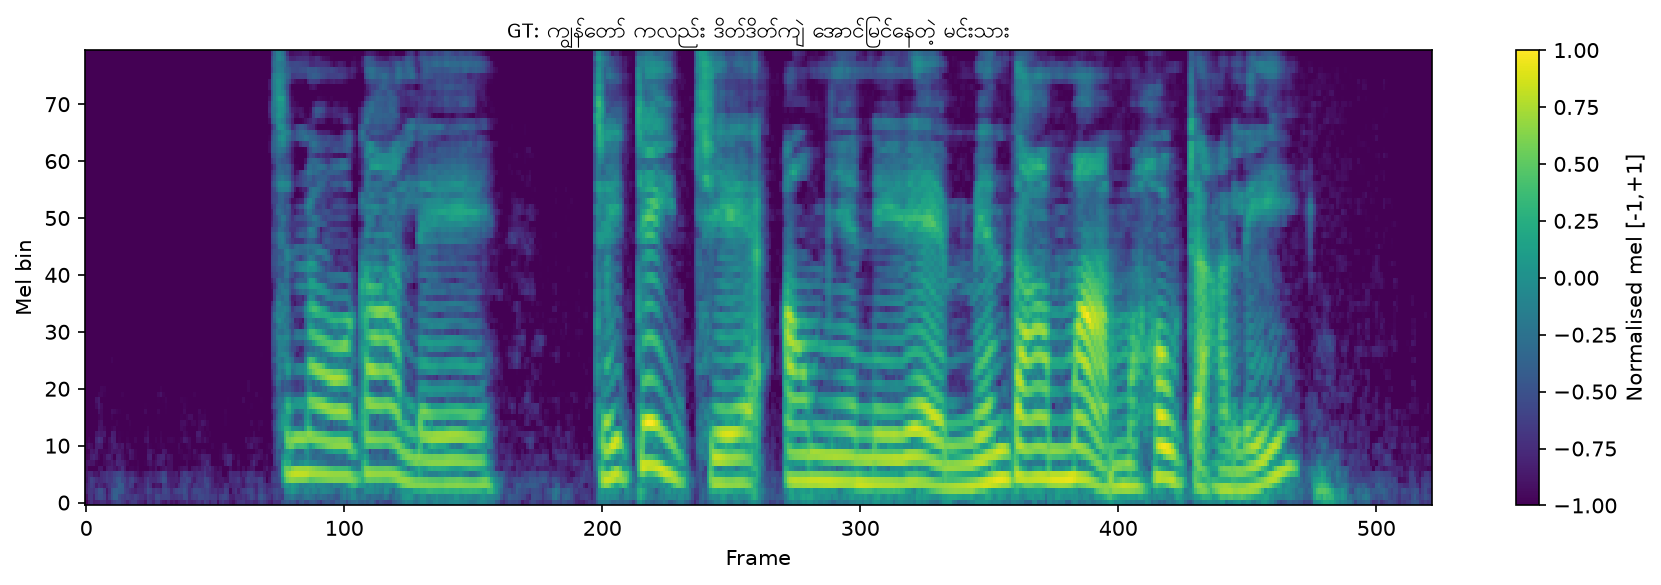

In [10]:
import IPython.display as ipd
from IPython.display import Image

GT_PATH = current_dir / "tts_output" / "v6_exp_1.2" / "gt_output"

ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_5362_4875790905.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_5362_4875790905.png"))

### Example Sample 2 - WaveGlow

In [11]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage synth \
  --output_dir "./tts_output/v6_exp_1.2" \
  --gt_sample_id bur_8266_7413365509 \
  --synth_out "./tts_output/v6_exp_1.2/gt_output/gt_bur_8266_7413365509.wav" \
  --vocoder waveglow

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
2026-09

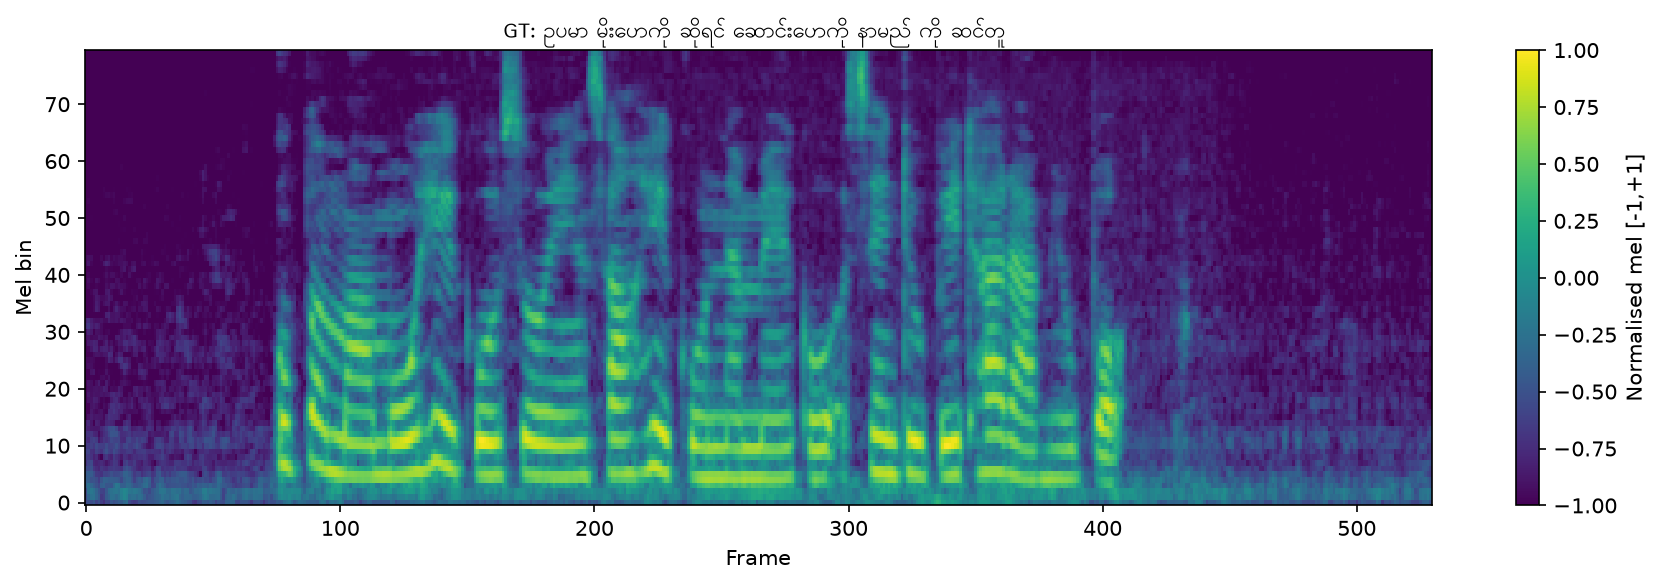

In [12]:
ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_8266_7413365509.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_8266_7413365509.png"))

### Example Sample 3 - Griffin-Lim

In [13]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage synth \
  --output_dir "./tts_output/v6_exp_1.2" \
  --gt_sample_id bur_5932_6467856225 \
  --synth_out "./tts_output/v6_exp_1.2/gt_output/gt_bur_5932_6467856225.wav" \
  --no_neural_vocoder

2026-09-24 20:59:51  [INFO    ]  Vocoder: Griffin-Lim
2026-09-24 20:59:51  [INFO    ]  Found bur_5932_6467856225 in train
2026-09-24 20:59:51  [INFO    ]  GT text: ရုပ်ရှင်ကားကြီးတွေ ရိုက်ရင် ဖလင် က တအား ကုန်တယ်
2026-09-24 20:59:51  [INFO    ]  GT mel: min=-80.0 max=0.0 mean=-52.6 dB  shape=(317, 80)
2026-09-24 20:59:56  [INFO    ]  Mel plot → tts_output/v6_exp_1.2/gt_output/gt_bur_5932_6467856225.png
2026-09-24 20:59:56  [INFO    ]  GT audio → tts_output/v6_exp_1.2/gt_output/gt_bur_5932_6467856225.wav  (3.67s)

real	0m7.630s
user	0m12.634s
sys	0m0.566s


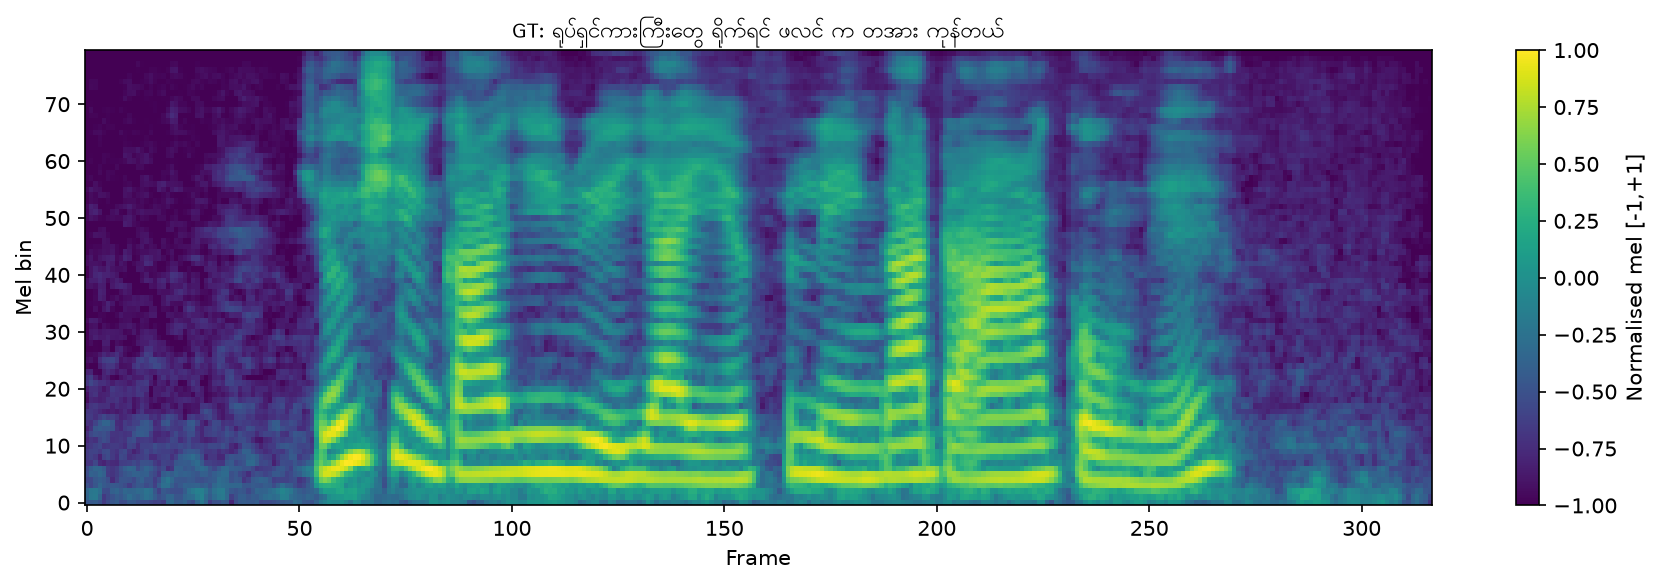

In [14]:
ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_5932_6467856225.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_5932_6467856225.png"))

## Testing (Prediction)

### Longer Prediction

In [15]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage synth \
  --output_dir "./tts_output/v6_exp_1.2" \
  --synth_text "ကျွန်တော် ကလည်း ဒိတ်ဒိတ်ကျဲ အောင်မြင်နေတဲ့ မင်းသား မှ မဟုတ်တာလေ" \
  --synth_out "./tts_output/v6_exp_1.2/gt_output/gt_bur_5362_4875790905_synthesized.wav" \
  --gt_compare

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
HiFi-GAN: Removing weight norm.
2026-09-24 21:00:07  [INFO    ]  HiFi-GAN loaded ✓  (NVIDIA torch.hub)
2026-09-24 21:00:09  [INFO    ]  Loaded TransformerTTS: epoch=48 dev=0.3077
2026-09-24 21:00:09  [INFO    ]  Synthesizing: 'ကျွန

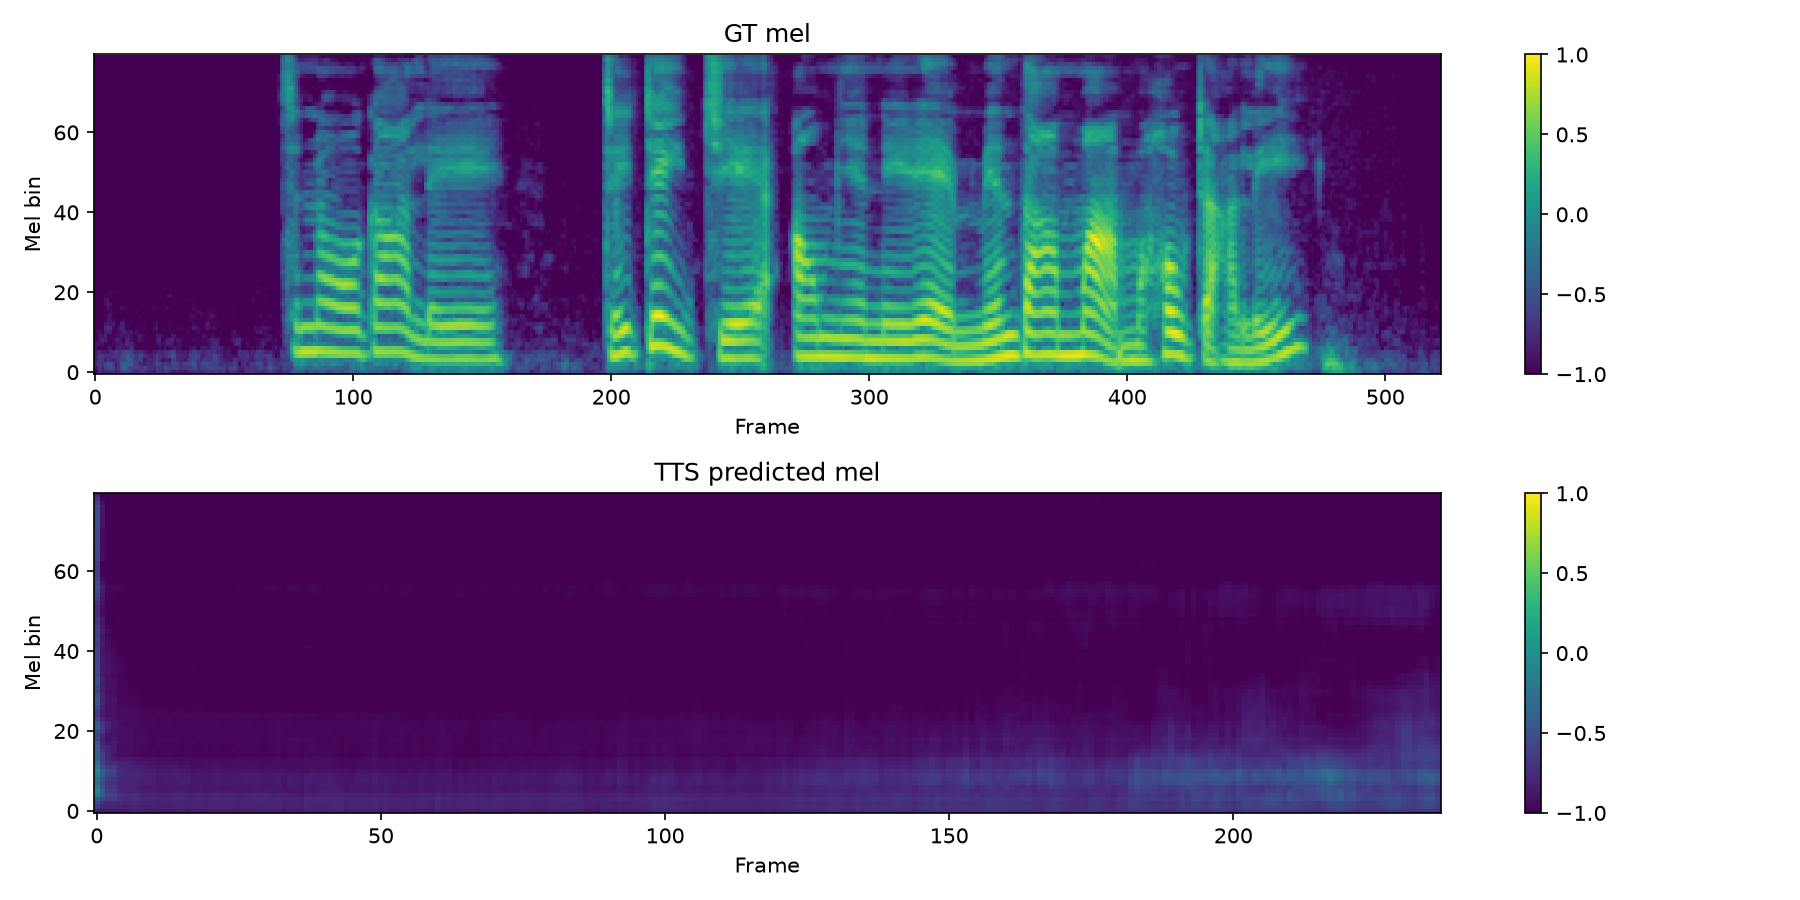

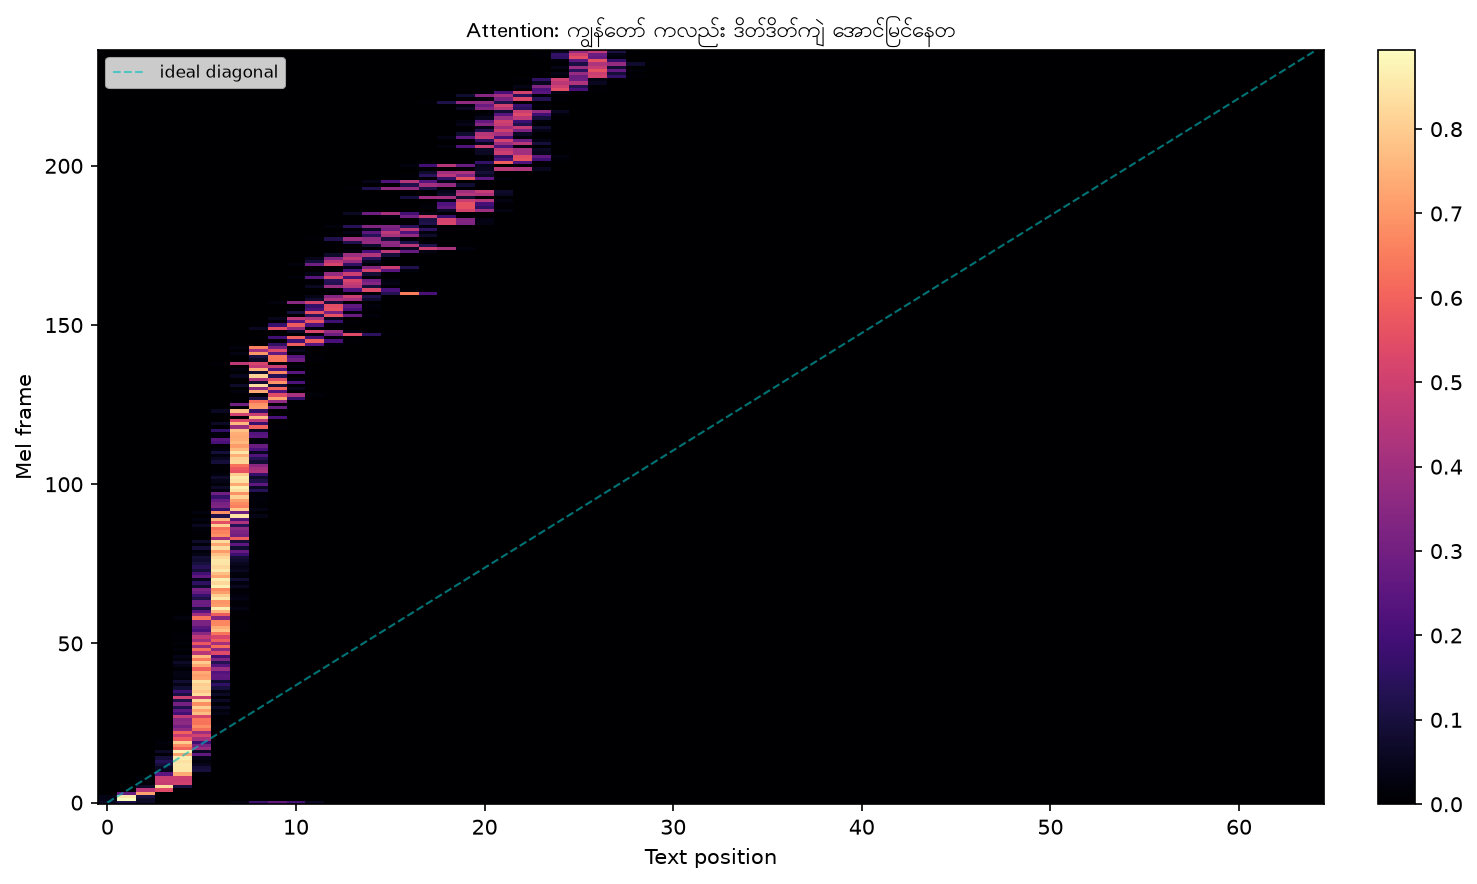

In [16]:
ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_5362_4875790905_synthesized_GT.wav"))
ipd.display(ipd.Audio(f"{GT_PATH}/gt_bur_5362_4875790905_synthesized.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_5362_4875790905_synthesized_compare.png"))
ipd.display(Image(filename=f"{GT_PATH}/gt_bur_5362_4875790905_synthesized_attn.png"))

### Shorter Prediction

In [17]:
!time python {SRC}/myanmar_tts_transformer_v6.py --stage synth \
  --output_dir "./tts_output/v6_exp_1.2" \
  --synth_text "ရုပ်ရှင်ကားကြီးတွေ" \
  --synth_out "./tts_output/v6_exp_1.2/gt_output/gt_custom_synthesized.wav" \
  --gt_compare

/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/home/lawun330/anaconda3/envs/lu_aief_asr_tts_env/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:145: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
HiFi-GAN: Removing weight norm.
2026-09-24 21:26:46  [INFO    ]  HiFi-GAN loaded ✓  (NVIDIA torch.hub)
2026-09-24 21:26:47  [INFO    ]  Loaded TransformerTTS: epoch=48 dev=0.3077
2026-09-24 21:26:47  [INFO    ]  Synthesizing: 'ရုပ်

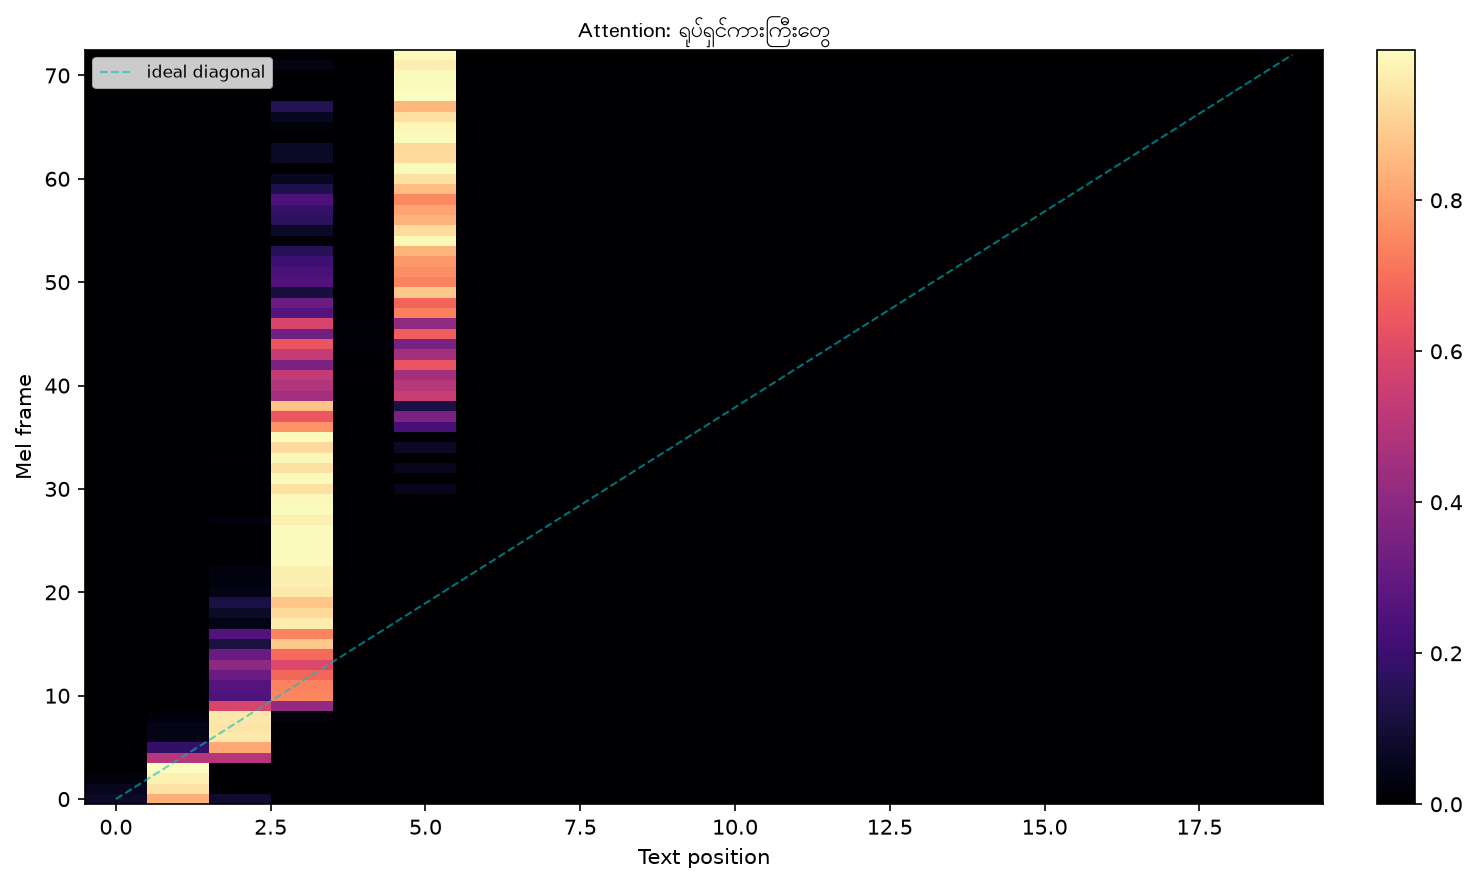

In [18]:
ipd.display(ipd.Audio(f"{GT_PATH}/gt_custom_synthesized.wav"))
ipd.display(Image(filename=f"{GT_PATH}/gt_custom_synthesized_attn.png"))